# Лабораторная работа 1.


Выберите датасет, в котором есть атрибут, который «хочется предсказывать» (неважно, бинарный, категориальный или количественный он). Предварительно обработайте данные (разобраться с пропусками и т.п.). Разбейте выборку на обучающую и тестовую (можно «наивным» способом, хоть кроссвалидация действительно имеет место быть).

Выявите статистически значимые факторы (сначала можно порисовать картинки, потом провести стат. тесты)
Обучите какую-нибудь ML-модель на выявленных статистически значимых факторах
Посмотрите, как оно работает на тестовой выборки

Задание звучит довольно-таки творчески, так что приведём конкретные требования, исходя из которых будет оцениваться само решение:

Описана в общих чертах ML-модель или приведена ссылка на документацию/статью, откуда брали ML-модель.
Для ML-модели выводится значение функции потерь на обучающей и тестовой выборках (вывод других метрик качества опционален).
Как минимум два теста реализованы самостоятельно, причем должны выводиться статистика критерия, p-value, области принятия и критическая области. Минимальное количество уникальных применений стат. тестов — 4 (среди них 2 вызова самостоятельно реализованных тестов)
Нужно выявить хотя бы 1 статистически значимый фактор.

![oppossum](https://cdn.wmnf.org/wp-content/uploads/2022/06/Flower-Baby-7x7-1-1024x1024.jpg)

## Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from pathlib import Path
import kagglehub

## Скачивание данных

In [2]:
dataset_dir = Path(kagglehub.dataset_download("abrambeyer/openintro-possum"))
csv_path = next(dataset_dir.rglob("possum.csv"))
print("CSV найден тут:", csv_path)

data = pd.read_csv(csv_path)
data.head()

CSV найден тут: C:\Users\shaki\.cache\kagglehub\datasets\abrambeyer\openintro-possum\versions\1\possum.csv


,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


## Датасет

In [3]:
# Проверим наличие пропусков
print(data.isnull().sum())

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [4]:
# Два пропуска в возрасте и один пропуск в длине ноги
# Заполним пропуски медианой
data['age'] = data['age'].fillna(data['age'].median())
data['footlgth'] = data['footlgth'].fillna(data['footlgth'].median())
print(data.isnull().sum())

case        0
site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [5]:
# Удалим колонки 'site' и 'Pop', так как не являются классами в зависимости от места обитания, что не является интересным для нашей задачи на данном этапе
# Также удалим колонку 'case', так как она не несет полезной информации для модели
data = data.drop(['site', 'Pop', 'case'], axis=1)

In [6]:
# Разделим выборку на обучающую и тестовую
# Целевая переменная - длина головы (hdlngth)
X = data.drop('hdlngth', axis=1)
y = data['hdlngth']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=465440)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(83, 10) (21, 10) (83,) (21,)


## Анализ данных

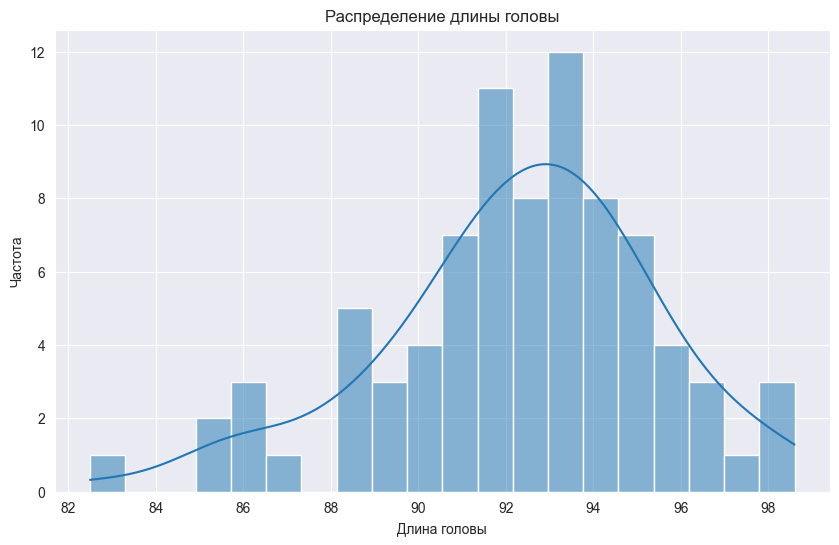

In [7]:
# Посмотрим на распределение длины головы
plt.figure(figsize=(10, 6))
sns.histplot(y_train, bins=20, kde=True)
plt.title('Распределение длины головы')
plt.xlabel('Длина головы')
plt.ylabel('Частота')
plt.show()

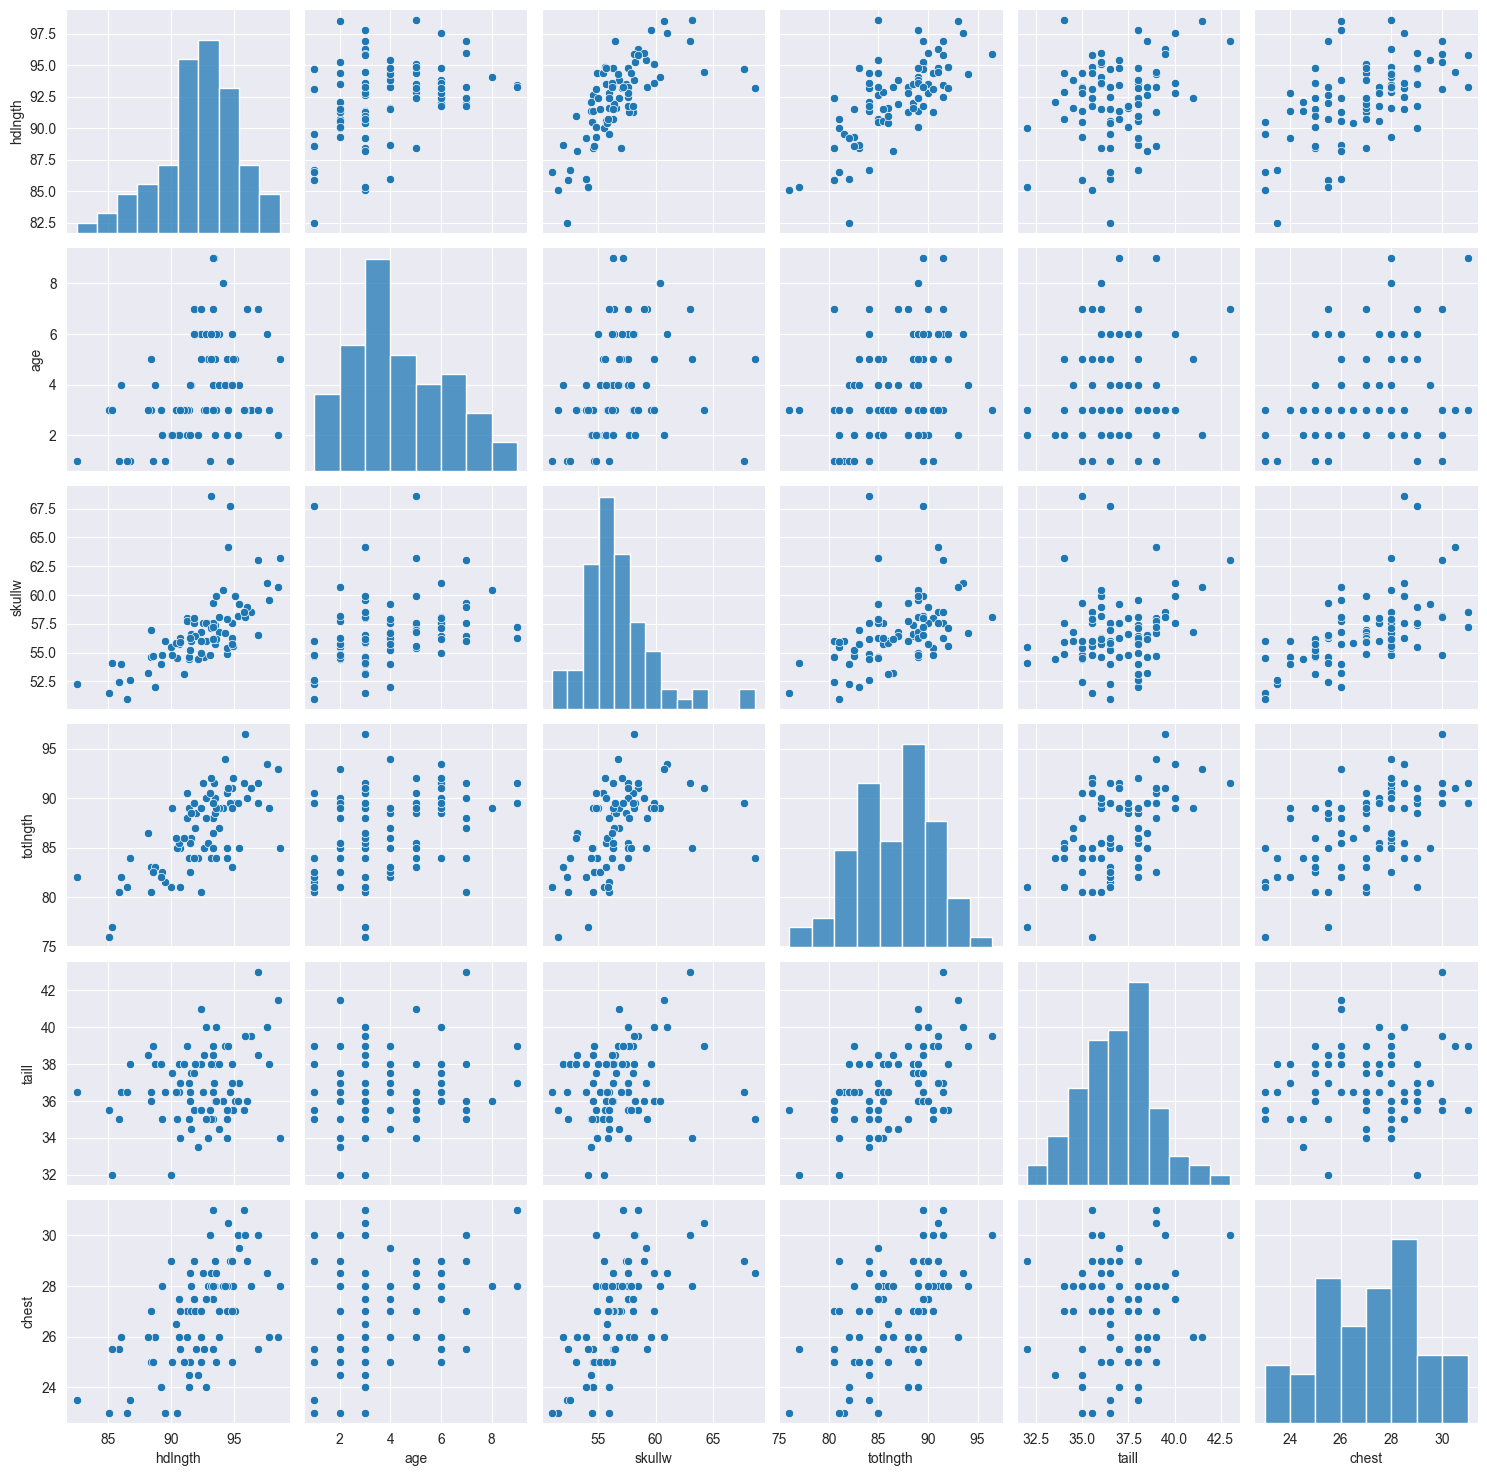

<Axes: >

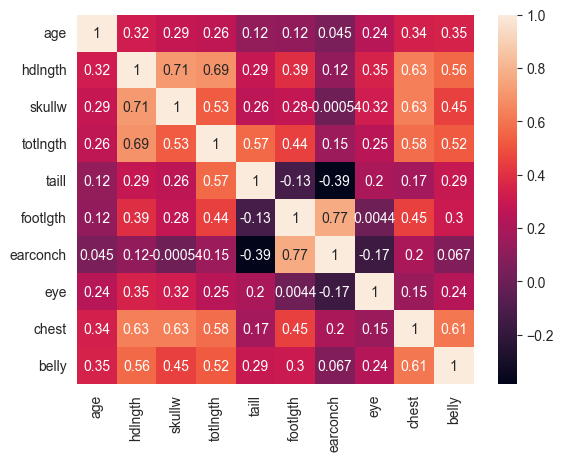

In [8]:
# Рассмотрим зависимость длины головы от других переменных с помощью парных графиков
sns.pairplot(
    pd.concat(
        [y_train,
         X_train[['age', 'skullw', 'totlngth', 'taill', 'chest']]], axis=1)
)
plt.show()
sns.heatmap(data.corr(numeric_only=True), annot=True)

## Проверим связь длины головы и возраста (тест Пирсона)

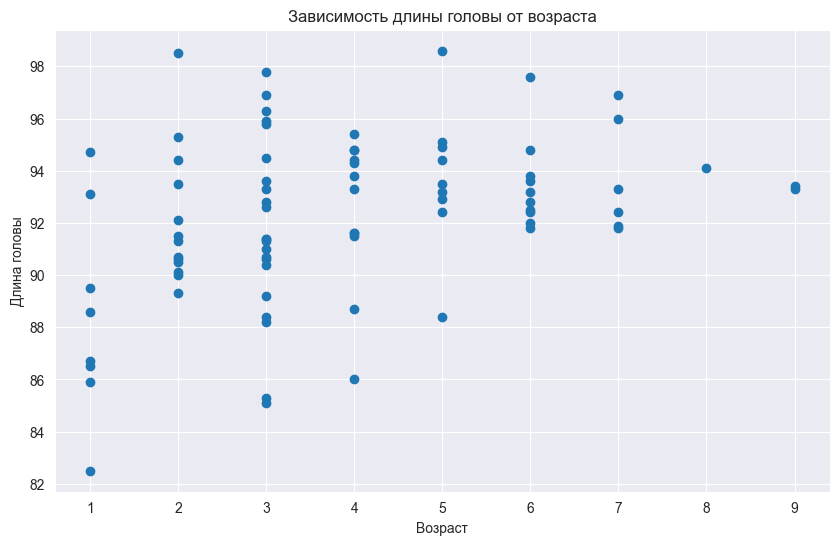

In [9]:
# Выведем график зависимости длины головы от возраста
plt.figure(figsize=(10, 6))
plt.scatter(X_train['age'], y_train)
plt.title('Зависимость длины головы от возраста')
plt.xlabel('Возраст')
plt.ylabel('Длина головы')
plt.show()

Проверим на нормальность распределения переменных с помощью теста Жарка-Бера, так как тест Пирсона требует нормальности данных.
В тесте Жарка-Бера:
- Нулевая гипотеза (H0): Данные распределены нормально
- Альтернативная гипотеза (H1): Данные не распределены нормально
- Уровень значимости (alpha): 0.05

In [10]:
# Тест Жарка-Бера для проверки нормальности распределения возраста
_, jb_p_value = stats.jarque_bera(X_train['age'])
print(f"p-value для теста Жарка-Бера для возраста: {jb_p_value:.4f}")

p-value для теста Жарка-Бера для возраста: 0.0893


In [11]:
# Тест Жарка-Бера для проверки нормальности распределения длины головы
_, jb_p_value = stats.jarque_bera(y_train)
print(f"p-value для теста Жарка-Бера для длины головы: {jb_p_value:.4f}")

p-value для теста Жарка-Бера для длины головы: 0.0652


Результаты теста Жарка–Бера не дают оснований отвергнуть гипотезу
о нормальности распределений переменных. Следовательно,
использование параметрического критерия Пирсона является допустимым.

Теперь проведем тест Пирсона для проверки корреляции между возрастом и длиной головы. В тесте Пирсона:
- Нулевая гипотеза (H0): Между возрастом и длиной головы нет корреляции
- Альтернативная гипотеза (H1): Между возрастом и длиной головы есть корреляция
- Уровень значимости (alpha): 0.05

Формула для расчёта коэффициента корреляции Пирсона (r) между двумя переменными X и Y:
$$
r = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
$$
Далее, для проверки статистической значимости корреляции, мы можем использовать t-статистику, которая рассчитывается следующим образом:
$$
t = r \sqrt{\frac{n - 2}{1 - r^2}}
$$
где n - количество наблюдений. При условии H0, t-статистика распределяется по t-распределению с n-2 степенями свободы.

In [12]:
# Тест Пирсона для проверки корреляции между возрастом и длиной головы
pearson_corr, pearson_p_value = stats.pearsonr(X_train['age'], y_train)
print(f"Коэффициент корреляции Пирсона: {pearson_corr:.4f}, p-value: {pearson_p_value:.4f}")

Коэффициент корреляции Пирсона: 0.3633, p-value: 0.0007


In [13]:
# Вручную реализуем тест Пирсона
def pearson_test_manual(x, y, alpha=0.05):
    n = len(x)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    up = np.sum((x - mean_x) * (y - mean_y))
    down = np.sqrt(np.sum((x - mean_x) ** 2) * np.sum((y - mean_y) ** 2))

    r = up / down
    t = r * np.sqrt((n - 2) / (1 - r ** 2))

    critical_value = stats.t.ppf(1 - alpha / 2, df=n - 2)
    p_value = 2 * (1 - stats.t.cdf(abs(t), df=n - 2))
    print(
        f"Коэффициент корреляции Пирсона: {r:.4f}, t-статистика: {t:.4f}, критическое значение: {critical_value:.4f}, p-value: {p_value:.4f}")


pearson_test_manual(X_train['age'], y_train)

Коэффициент корреляции Пирсона: 0.3633, t-статистика: 3.5094, критическое значение: 1.9897, p-value: 0.0007


Значения тестов совпадают, значит функция реализована верно. Результат говорит о том, что мы должно что мы отвергаем нулевую гипотезу о том, что между возрастом и длиной головы нет корреляции, так как p-value для теста Пирсона ниже стандартного уровня значимости 0.05. Коэффициент корреляции Пирсона показывает 0.36 - умеренную положительную корреляцию между возрастом и длиной головы, что означает, что с увеличением возраста длина головы имеет тенденцию увеличиваться.

## Проверка связи длины головы и размера ушной раковины (тест Кенделла)

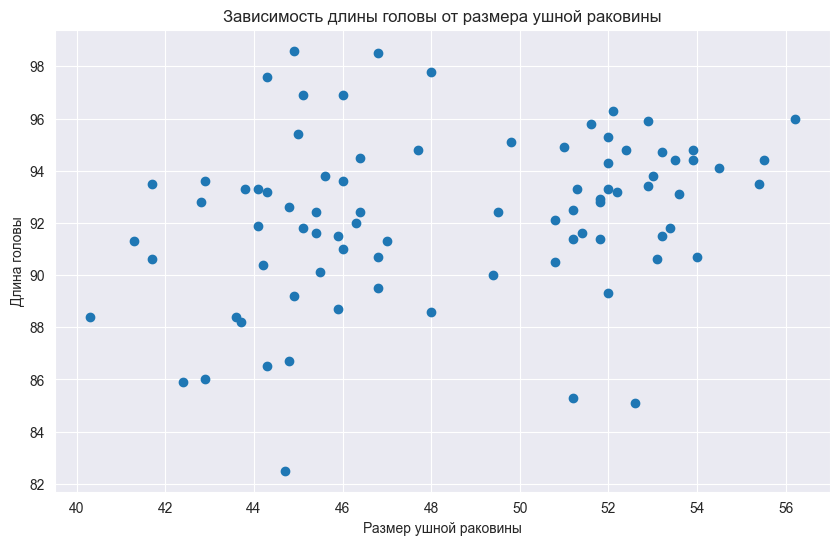

In [14]:
# Выведем график зависимости длины головы от размера ушной раковины
plt.figure(figsize=(10, 6))
plt.scatter(X_train['earconch'], y_train)
plt.title('Зависимость длины головы от размера ушной раковины')
plt.xlabel('Размер ушной раковины')
plt.ylabel('Длина головы')
plt.show()

In [15]:
# Число наблюдений
n = len(X_train)
# Число уникальных наблюдений длин головы и размера ушной раковины
unique_observations_earconch = len(X_train['earconch'].unique())
unique_observations_hdlngth = len(y_train.unique())
print(
    f"Число наблюдений: {n}, Число уникальных наблюдений размера ушной раковины: {unique_observations_earconch}, Число уникальных наблюдений длины головы: {unique_observations_hdlngth}"
)

Число наблюдений: 83, Число уникальных наблюдений размера ушной раковины: 56, Число уникальных наблюдений длины головы: 60


https://math.semestr.ru/corel/kendel.php

Поскольку в данных присутствуют повторяющиеся значения, используем скорректированный
коэффициент Кенделла ($tau_b$), который учитывает наличие связных рангов. В тесте Кенделла:
- Нулевая гипотеза (H0): Между размером ушной раковины и длиной головы нет монотонной зависимости
- Альтернативная гипотеза (H1): Между размером ушной раковины и длиной головы есть монотонная зависимость
- Уровень значимости (alpha): 0.05

Скорректированный коэффициент Кенделла ($tau_b$) рассчитывается по формуле:
$$
\tau_b = \frac{P - Q}{\sqrt{(n_0 - n_x)(n_0 - n_y)}}
$$
где:
- $P$ - количество пар наблюдений, которые согласованы
- $Q$ - количество пар наблюдений, которые не согласованы
- $n_0 = \frac{n(n-1)}{2}$ - общее количество пар наблюдений
- $n_x = \frac{1}{2} \sum_{i}^k t_i^x(t_i^x - 1)$ - поправка на связные ранги в переменной x, i - номер группы связей
- $n_y = \frac{1}{2} \sum_{j}^m t_j^y(t_j^y - 1)$ - поправка на связные ранги в переменной y, j - номер группы связей
- $t_i^x$ - количество наблюдений в i-й группе связей для переменной x
- $t_j^y$ - количество наблюдений в j-й группе связей для переменной y

Статистика теста Кенделла рассчитывается следующим образом:
$$
z = \frac{\tau_b}{\sqrt{\frac{2(2n +5)}{9n(n-1)}}}
$$
При условии H0, z-статистика распределяется по стандартному нормальному распределению.

In [16]:
# Тест Кенделла для проверки монотонной зависимости между размером ушной раковины и длиной головы
kendall_corr, kendall_p_value = stats.kendalltau(X_train['earconch'], y_train)
print(f"Коэффициент Кенделла: {kendall_corr:.4f}, p-value: {kendall_p_value:.4f}")

Коэффициент Кенделла: 0.2151, p-value: 0.0043


In [17]:
# Вручную реализуем тест Кенделла
def kendall_tau_b_manual(x, y, alpha=0.05):
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    P = 0
    Q = 0
    n_x = 0
    n_y = 0
    for i in range(n):
        for j in range(i + 1, n):
            if (x[i] < x[j] and y[i] < y[j]) or (x[i] > x[j] and y[i] > y[j]):
                P += 1
            elif (x[i] < x[j] and y[i] > y[j]) or (x[i] > x[j] and y[i] < y[j]):
                Q += 1
            if x[i] == x[j]:
                n_x += 1
            if y[i] == y[j]:
                n_y += 1
    n_0 = n * (n - 1) / 2
    tau_b = (P - Q) / np.sqrt((n_0 - n_x) * (n_0 - n_y))
    z = tau_b / np.sqrt(2 * (2 * n + 5) / (9 * n * (n - 1)))
    critical_value = stats.norm.ppf(1 - alpha / 2)
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    print(
        f"Коэффициент Кенделла: {tau_b:.4f}, z-статистика: {z:.4f}, критическое значение: {critical_value:.4f}, p-value: {p_value:.4f}"
    )


kendall_tau_b_manual(X_train['earconch'], y_train)

Коэффициент Кенделла: 0.2151, z-статистика: 2.8783, критическое значение: 1.9600, p-value: 0.0040


Значения тестов совпадают, значит функция реализована верно. Результат говорит о том, что мы отвергаем нулевую гипотезу о том, что между размером ушной раковины и длиной головы нет монотонной зависимости, так как p-value для теста Кенделла ниже стандартного уровня значимости 0.05. Коэффициент Кенделла показывает 0.22 - слабую положительную монотонную зависимость между размером ушной раковины и длиной головы, что означает, что с увеличением размера ушной раковины длина головы имеет тенденцию увеличиваться.

## Проверим связь между полом и длиной головы

Так как переменная является категориальной и задаёт две независимые группы, для проверки связи между полом и длиной головы сравним значения признака `hdlngth` в этих группах.

**Проверка нормальности (тест Шапиро-Уилка)**

- $H_0$: данные в выборке имеют нормальное распределение.
- $H_1$: данные в выборке не имеют нормального распределения.

Статистика критерия Шапиро-Уилка рассчитывается по формуле:
$$
W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2},
$$
где:
- $x_{(i)}$ - элементы выборки, упорядоченные по возрастанию,
- $\bar{x}$ - выборочное среднее,
- $a_i$ - коэффициенты, зависящие от объёма выборки и ожидаемых порядковых статистик нормального распределения.

In [18]:
df_sex = pd.DataFrame({
    'sex': X_train['sex'],
    'hdlngth': y_train
}).dropna().copy()

male = df_sex.loc[df_sex['sex'] == 'm', 'hdlngth']
female = df_sex.loc[df_sex['sex'] == 'f', 'hdlngth']

print(f'Размер группы m: {len(male)}')
print(f'Размер группы f: {len(female)}')

Размер группы m: 50
Размер группы f: 33


In [19]:
_, p_value_skull = stats.shapiro(male)
print(f"p-value для male: {p_value_skull:.4f}")

_, p_value_head = stats.shapiro(female)
print(f"p-value для female: {p_value_head:.4f}")

p-value для male: 0.2442
p-value для female: 0.5813


В результате применения библиотечного теста получено:

- для группы `m`: `p-value = 0.2442`,
- для группы `f`: `p-value = 0.5813`.

Так как в обоих случаях `p-value > 0.05`, нет оснований отвергать нулевую гипотезу о нормальности распределения. Следовательно, можно использовать F-тест.

**Проверка равенства дисперсий (F-тест Фишера)**

Перед применением классического $t$-теста Стьюдента необходимо проверить гипотезу о равенстве дисперсий в двух группах.
- $H_0$: дисперсии длины головы в группах `m` и `f` равны.
- $H_1$: дисперсии длины головы в группах `m` и `f` различаются.

Статистика критерия рассчитывается как отношение выборочных дисперсий:
$$
F = \frac{s_m^2}{s_f^2},
$$
где:
- $s_m^2$ - выборочная дисперсия в группе `m`,
- $s_f^2$ - выборочная дисперсия в группе `f`.

При условии справедливости $H_0$ статистика $F$ имеет распределение Фишера с числами степеней свободы:

$$
df_1 = n_m - 1, \quad df_2 = n_f - 1.
$$


In [20]:
var_m = male.var(ddof=1)
var_f = female.var(ddof=1)

print(f"Выборочная дисперсия для m: {var_m:.4f}")
print(f"Выборочная дисперсия для f: {var_f:.4f}")

# F-статистика
F = var_m / var_f

# степени свободы
df1 = len(male) - 1
df2 = len(female) - 1

# двустороннее p-value
p_value_f = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
p_value_f = min(p_value_f, 1.0)

print(f"F-статистика: {F:.4f}")
print(f"p-value: {p_value_f:.4f}")

Выборочная дисперсия для m: 12.8655
Выборочная дисперсия для f: 5.7692
F-статистика: 2.2300
p-value: 0.0182


В результате получено:

- выборочная дисперсия для `m`: `12.8655`,
- выборочная дисперсия для `f`: `5.7692`,

- `F = 2.2300`,
- `p-value = 0.0182`.

Так как `p-value < 0.05`, нулевая гипотеза отвергается. Следовательно, дисперсии длины головы в группах, выделенных по полу, статистически значимо различаются.

Это означает, что классический $t$-тест Стьюдента, предполагающий равенство дисперсий, применять не следует.

**t-тест Уэлча**

Так как нормальность в группах не отвергается, но гипотеза о равенстве дисперсий отвергается, для сравнения средних значений длины головы используем $t$-тест Уэлча.

- $H_0$ средняя длина головы одинакова в группах `m` и `f`.
- $H_1$ средняя длина головы различается в группах `m` и `f`.

Статистика критерия Уэлча рассчитывается по формуле:
$$
t = \frac{\bar{x}_m - \bar{x}_f}{\sqrt{\frac{s_m^2}{n_m} + \frac{s_f^2}{n_f}}},
$$
где:
- $\bar{x}_m, \bar{x}_f$ - выборочные средние в группах,
- $s_m^2, s_f^2$ - выборочные дисперсии,
- $n_m, n_f$ - объёмы выборок.

Число степеней свободы приближённо вычисляется по формуле:

$$
\nu =
\frac{\left(\frac{s_m^2}{n_m} + \frac{s_f^2}{n_f}\right)^2}
{\frac{\left(\frac{s_m^2}{n_m}\right)^2}{n_m - 1} + \frac{\left(\frac{s_f^2}{n_f}\right)^2}{n_f - 1}}.
$$

In [21]:
t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-статистика: -0.0042
p-value: 0.9966


В результате применения теста получено:
- `t = -0.0042`,
- `p-value = 0.9966`.

Так как `p-value > 0.05`, нет оснований отвергать нулевую гипотезу. Следовательно, статистически значимых различий средней длины головы между группами, выделенными по полу, не обнаружено.

Таким образом, по имеющимся данным пол не оказывает статистически значимого влияния на длину головы.

## Проверим связь между шириной черепа и длиной головы (тест Спирмена)

**Тест Шапиро-Уилка:**

- $H_0$ данные в выборке имеют нормальное распределение.
- $H_1$ данные в выборке не имеют нормального распределения.

Статистика критерия Шапиро-Уилка рассчитывается по формуле:
$$
W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}.
$$

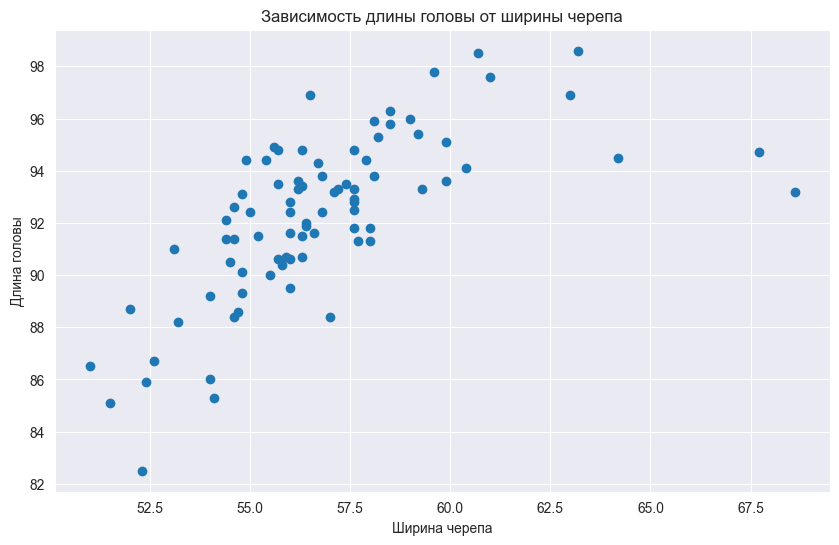

p-value для черепа: 0.0000
p-value для головы: 0.0812


In [22]:
df_skull = pd.DataFrame({
    'skullw': X_train['skullw'],
    'hdlngth': y_train
}).dropna()

plt.figure(figsize=(10, 6))
plt.scatter(df_skull['skullw'], df_skull['hdlngth'])
plt.title('Зависимость длины головы от ширины черепа')
plt.xlabel('Ширина черепа')
plt.ylabel('Длина головы')
plt.grid(True)
plt.show()

_, p_value_skull = stats.shapiro(df_skull['skullw'])
print(f"p-value для черепа: {p_value_skull:.4f}")

_, p_value_head = stats.shapiro(df_skull['hdlngth'])
print(f"p-value для головы: {p_value_head:.4f}")

В результате применения теста получено:

- для `skullw`: `p-value = 0.0000`,
- для `hdlngth`: `p-value = 0.0812`.

Так как для признака `skullw` `p-value < 0.05`, нулевая гипотеза о нормальности отвергается. Для признака `hdlngth` `p-value > 0.05`, следовательно, нет оснований отвергать гипотезу о нормальности.

Так как хотя бы для одной из переменных гипотеза о нормальности отвергается, использовать критерий Пирсона в данном случае некорректно. Поэтому для проверки зависимости используем коэффициент ранговой корреляции Спирмена.

**Тест Спирмена**

- $H_0$ между шириной черепа и длиной головы отсутствует монотонная зависимость.
- $H_1$ между шириной черепа и длиной головы существует монотонная зависимость.

Коэффициент Спирмена рассчитывается следующим образом:

$$
\rho_s =
\frac{\sum_{i=1}^{n}(R_i - \bar{R})(S_i - \bar{S})}
{\sqrt{\sum_{i=1}^{n}(R_i - \bar{R})^2}\sqrt{\sum_{i=1}^{n}(S_i - \bar{S})^2}},
$$

где:
- $R_i$ - ранг значения $x_i$,
- $S_i$ - ранг значения $y_i$,
- $\bar{R}, \bar{S}$ - средние ранги.

In [23]:
rho, p_value = stats.spearmanr(df_skull['skullw'], df_skull['hdlngth'])
print(f"Коэффициент Спирмена: {rho:.4f}, p-value: {p_value:.4f}")

Коэффициент Спирмена: 0.7362, p-value: 0.0000


In [24]:
len(X_train['skullw'].unique())

56

Повторов немного, будут применены поправки к статистике.

В результате применения библиотечного теста получено:
- коэффициент Спирмена: `0.7362`,
- `p-value = 0.0000`.

Так как `p-value < 0.05`, нулевая гипотеза отвергается. Следовательно, между шириной черепа и длиной головы существует статистически значимая монотонная зависимость.

## Линейная регрессия

Построим модель линейной регрессии, используя только статистически значимые признаки, выявленные ранее при помощи статистических критериев.

В качестве признаков в модель включаются следующие признаки:

- `age`
- `earconch`
- `skullw`

После обучения модели вычисляются предсказания на тренировочной и тестовой выборках. Для оценки качества используются:

- $MAE$,
- $RMSE$,
- $R^2$

In [25]:
significant_features = ['age', 'earconch', 'skullw']

X_train_sig = X_train[significant_features].copy()
X_test_sig = X_test[significant_features].copy()

model = LinearRegression()
model.fit(X_train_sig, y_train)

y_pred_train = model.predict(X_train_sig)
y_pred_test = model.predict(X_test_sig)

In [26]:
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("Метрики на train:")
print(f"MAE = {mae_train:.4f}")
print(f"RMSE = {rmse_train:.4f}")
print(f"R^2 = {r2_train:.4f}")

print("\nМетрики на test:")
print(f"MAE = {mae_test:.4f}")
print(f"RMSE = {rmse_test:.4f}")
print(f"R^2 = {r2_test:.4f}")

Метрики на train:
MAE = 1.6347
RMSE = 2.1687
R^2 = 0.5210

Метрики на test:
MAE = 2.6669
RMSE = 3.5485
R^2 = 0.4208


Модель действительно обобщает данные, но возможно, трех признаков недостаточно для точного описания длины головы, так как все статистически значимые факторы не были выявлены.

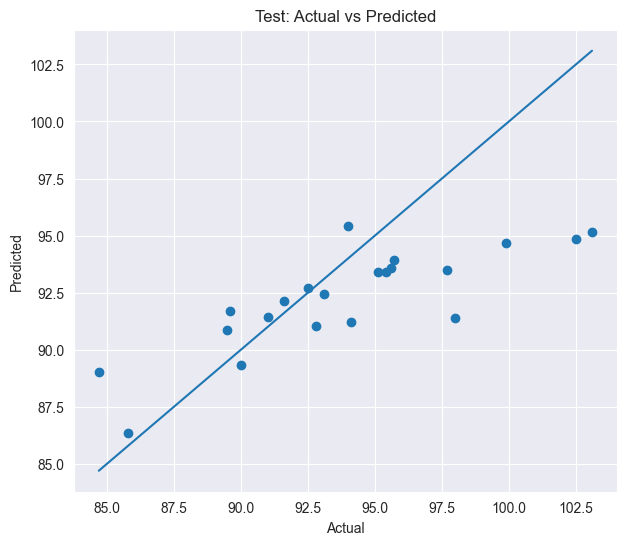

In [27]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Test: Actual vs Predicted")
plt.grid(True)

mn = min(np.min(y_test), np.min(y_pred_test))
mx = max(np.max(y_test), np.max(y_pred_test))
plt.plot([mn, mx], [mn, mx])
plt.show()

Для сравнения обучим модель на всем датасете.

In [28]:
X_train['sex'] = X_train['sex'].map({'f': 0, 'm': 1})
X_test['sex'] = X_test['sex'].map({'f': 0, 'm': 1})

model_all = LinearRegression()
model_all.fit(X_train, y_train)

y_pred_train_all = model_all.predict(X_train)
y_pred_test_all = model_all.predict(X_test)

In [29]:
mae_train_all = mean_absolute_error(y_train, y_pred_train_all)
rmse_train_all = np.sqrt(mean_squared_error(y_train, y_pred_train_all))
r2_train_all = r2_score(y_train, y_pred_train_all)

mae_test_all = mean_absolute_error(y_test, y_pred_test_all)
rmse_test_all = np.sqrt(mean_squared_error(y_test, y_pred_test_all))
r2_test_all = r2_score(y_test, y_pred_test_all)

print("Метрики на train:")
print(f"MAE = {mae_train_all:.4f}")
print(f"RMSE = {rmse_train_all:.4f}")
print(f"R^2 = {r2_train_all:.4f}")

print("\nМетрики на test:")
print(f"MAE = {mae_test_all:.4f}")
print(f"RMSE = {rmse_test_all:.4f}")
print(f"R^2 = {r2_test_all:.4f}")

Метрики на train:
MAE = 1.2751
RMSE = 1.6565
R^2 = 0.7206

Метрики на test:
MAE = 2.4340
RMSE = 2.9824
R^2 = 0.5909


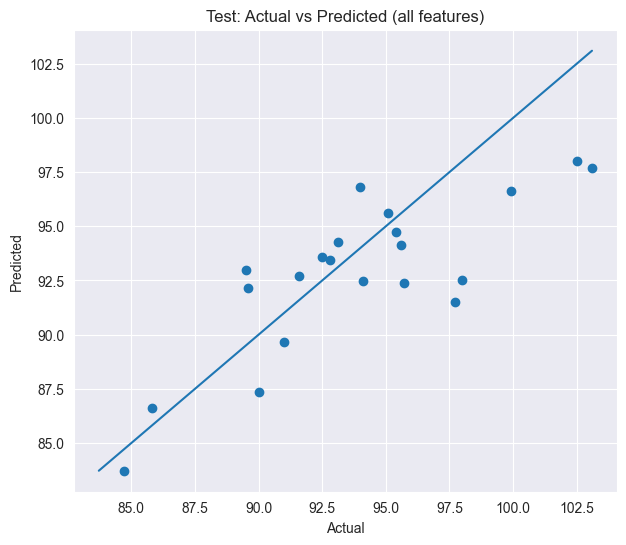

In [30]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_test_all)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Test: Actual vs Predicted (all features)")
plt.grid(True)

mn = min(np.min(y_test), np.min(y_pred_test_all))
mx = max(np.max(y_test), np.max(y_pred_test_all))
plt.plot([mn, mx], [mn, mx])
plt.show()

In [31]:
print("Сравнение моделей на test:")
print(f"Только значимые признаки: MAE = {mae_test:.4f}, RMSE = {rmse_test:.4f}, R^2 = {r2_test:.4f}")
print(f"Все признаки: MAE = {mae_test_all:.4f}, RMSE = {rmse_test_all:.4f}, R^2 = {r2_test_all:.4f}")

Сравнение моделей на test:
Только значимые признаки: MAE = 2.6669, RMSE = 3.5485, R^2 = 0.4208
Все признаки: MAE = 2.4340, RMSE = 2.9824, R^2 = 0.5909


Хотя использование только статистически значимых признаков не даёт наилучшего качества прогноза, полученная модель всё же демонстрирует умеренную обобщающую способность на тестовой выборке. Это означает, что найденные признаки действительно являются информативными, однако они не показывают всю информацию, необходимую для наиболее точного предсказания.